# Model Scores & PCA Correlations

Altair exploration of `test_scores.csv` and `pca_correlations.csv`.


In [164]:
import altair as alt
import pandas as pd
from pathlib import Path

alt.data_transformers.disable_max_rows()

# Resolve repo root
root = Path.cwd().resolve()
marker = Path('configs/analysis/embeddings_probe_runs.toml')
if not (root / marker).exists():
    for parent in root.parents:
        if (parent / marker).exists():
            root = parent
            break

scores_path = root / 'analysis/embeddings_probe/test_scores.csv'
pca_path = root / 'analysis/embeddings_probe/pca_correlations.csv'

scores = pd.read_csv(scores_path)
pca = pd.read_csv(pca_path)

# Keep only PCA correlations for enc space if present
if 'space' in pca.columns:
    pca = pca[pca['space'] == 'enc']

df = scores.merge(pca, on='run_id', how='left', suffixes=('', '_pca'))
df.head()


,run_id,track,preprocessing,checkpoint_path,N,N_pos,N_neg,loss,axisrot,auroc,...,space,corr_chagas_pc1_pca,corr_chagas_pc2_pca,n_chagas_pca,corr_age_pc1_pca,corr_age_pc2_pca,n_age_pca,corr_rbbb_code15_pc1_pca,corr_rbbb_code15_pc2_pca,n_rbbb_code15_pca
0,t1-exp01-bp-bce,t1,bp,ag-lukassen/ecg-chagas-embeddings-cli/model-pk...,73236,1631,71605,bce,False,0.833916,...,enc,-0.554216,0.116723,4893.0,-0.048366,0.084964,4893.0,-0.248633,0.199181,2950.0
1,t1-exp02-bp-bce-rot10,t1,bp,ag-lukassen/ecg-chagas-embeddings-cli/model-ox...,73236,1631,71605,bce,True,0.600172,...,enc,-0.597195,0.116376,4893.0,-0.085635,0.114489,4893.0,-0.279474,0.184637,2950.0
2,t1-exp03-bp-focal,t1,bp,ag-lukassen/ecg-chagas-embeddings-cli/model-0q...,73236,1631,71605,focal,False,0.838842,...,enc,-0.600341,-0.063618,4893.0,-0.132173,-0.197389,4893.0,-0.283288,-0.196718,2950.0
3,t1-exp04-bp-focal-rot10,t1,bp,ag-lukassen/ecg-chagas-embeddings-cli/model-ep...,73236,1631,71605,focal,True,0.837121,...,enc,0.616744,0.063029,4893.0,0.145767,0.233880,4893.0,0.286823,0.267433,2950.0
4,t1-exp05-bp-rat,t1,bp,ag-lukassen/ecg-chagas-embeddings-cli/model-01...,73236,1631,71605,rat,False,0.806557,...,enc,0.525131,-0.187470,4893.0,0.199511,0.098187,4893.0,0.578356,0.026372,2950.0


In [165]:
# Use the same model ordering logic as in consensus.ipynb

def parse_model_name(name):
    parts = name.split('-')
    track = parts[0]
    exp_num = int(parts[1].replace('exp', ''))
    rot = 'rot10' if parts[-1] == 'rot10' else 'none'
    loss_idx = -2 if rot == 'rot10' else -1
    loss = parts[loss_idx]
    prepro = '-'.join(parts[2:loss_idx])
    return pd.Series([track, exp_num, prepro, loss, rot],
                     index=['track','exp_num','prepro','loss','rot'])

# Sorting priority (edit if needed)
sort_by = ['prepro','track','loss']
features = df['run_id'].apply(parse_model_name)
_df_sort = pd.concat([df[['run_id']], features], axis=1)
model_order = _df_sort.sort_values(sort_by)['run_id'].unique().tolist()


## Preprocessing regime comparison
TPR@5% and AP by preprocessing (small multiples)


In [166]:
melt = df.melt(
    id_vars=['run_id', 'track', 'preprocessing'],
    value_vars=[c for c in ['auroc', 'tpr_top0.10', 'tpr_top0.05', 'ap', 'pauc_fpr0.05'] if c in df.columns],
    var_name='metric',
    value_name='value'
)
chart = (
    alt.Chart(melt)
    .mark_bar()
    .encode(
        x=alt.X('run_id:N', sort='-y', title=None),
        y=alt.Y('value:Q', title=None),
        color=alt.Color('track:N'),
        column=alt.Column('metric:N', title=None),
        tooltip=['run_id:N','track:N','preprocessing:N', alt.Tooltip('value:Q', format='.4f')]
    )
    .properties(width=180, height=220)
)
chart


alt.Chart(...)

In [167]:
alt.Chart(melt).mark_bar().encode(
    x=alt.X('metric:N', sort=model_order, title=None),
    y=alt.Y('value:Q', title=None),
    color=alt.Color('metric:N'),
    column=alt.Column('run_id:N', title=None),
    row=alt.Row('track:N', title=None),
    tooltip=['run_id:N','track:N','preprocessing:N', alt.Tooltip('value:Q', format='.4f')]
).properties(
    width=180,
    height=220
)

alt.Chart(...)

## Per‑model metric heatmap (custom order)
Scoring metrics + PCA correlations (`corr_*`) with model ordering matched to consensus.


## Per‑model metric heatmaps (normalized)\n

In [168]:
# --- Per‑model metric heatmaps (normalized per metric) ---

# Custom metric order (edit as needed)
overall_metrics = [
    'pauc_fpr0.05','ap','tpr_top0.05','tpr_top0.10','auroc',
]
verified_metrics = [
    'pauc_fpr0.05_verified','ap_verified','tpr_top0.05_verified','tpr_top0.10_verified','auroc_verified',
]
code15_metrics = [
    'pauc_fpr0.05_code15','ap_code15','tpr_top0.05_code15','tpr_top0.10_code15','auroc_code15',
]

# keep only columns that exist
overall_metrics = [m for m in overall_metrics if m in df.columns]
verified_metrics = [m for m in verified_metrics if m in df.columns]
code15_metrics = [m for m in code15_metrics if m in df.columns]

# normalize per metric for heatmap
def _normalize_per_metric(df_in, metrics):
    out = df_in[['run_id'] + metrics].copy()
    for m in metrics:
        col = out[m].astype(float)
        vmin = col.min()
        vmax = col.max()
        if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
            out[m] = 0.5
        else:
            out[m] = (col - vmin) / (vmax - vmin)
    return out

heat_overall = _normalize_per_metric(df, overall_metrics)
heat_verified = _normalize_per_metric(df, verified_metrics)
heat_code15 = _normalize_per_metric(df, code15_metrics)

# melt for Altair
heat_overall = heat_overall.melt('run_id', var_name='metric', value_name='value')
heat_verified = heat_verified.melt('run_id', var_name='metric', value_name='value')
heat_code15 = heat_code15.melt('run_id', var_name='metric', value_name='value')

# --- Per‑model metric heatmaps (normalized per metric) ---

color_scale = alt.Scale(scheme="viridis", domain=[0, 1])


def _heat(data, title, show_x=False):
    x_enc = alt.X(
        "run_id:N",
        sort=model_order,
        title="Model" if show_x else None,
        axis=alt.Axis(labelAngle=-90)
        if show_x
        else alt.Axis(labels=False, ticks=False),
    )
    return (
        alt.Chart(data)
        .mark_rect()
        .encode(
            x=x_enc,
            y=alt.Y("metric:N", title=None),
            color=alt.Color("value:Q", scale=color_scale, title="normalized"),
            tooltip=["run_id:N", "metric:N", alt.Tooltip("value:Q", format=".3f")],
        )
        .properties(
            width=18 * len(model_order),
            height=18 * len(data["metric"].unique()),
            title=title,
        )
    )


chart_overall = _heat(heat_overall, "Overall", show_x=False)
chart_verified = _heat(heat_verified, "Verified (PTB-XL + SaMi-Trop)", show_x=False)
chart_code15 = _heat(heat_code15, "Self-Reported (CODE-15)", show_x=True)

# stack vertically, share x-axis and color scale
(chart_overall & chart_verified & chart_code15).resolve_scale(
    x="shared", color="shared"
)


alt.VConcatChart(...)

## Overall score ordering (barplot)\n

In [169]:
# --- Barplot: overall normalized score per model ---
# Uses mean of normalized overall metrics (edit if you want a different aggregation)


norm_overall = _normalize_per_metric(df, overall_metrics)
norm_overall['score_mean'] = norm_overall[overall_metrics].mean(axis=1)
bar = (
    alt.Chart(norm_overall)
    .mark_bar()
    .encode(
        x=alt.X('run_id:N', sort='-y', title='Model'),
        y=alt.Y('score_mean:Q', title='Mean normalized score'),
        color=alt.Color('track:N'),
        tooltip=['run_id:N','track:N', alt.Tooltip('score_mean:Q', format='.3f')]
    )
    .properties(width=18*len(model_order), height=220)
)
bar



alt.Chart(...)

In [176]:
# --- PCA correlation heatmap (PC1/PC2 split; clean labels) ---
# Use the raw pca_correlations.csv to avoid _pca suffixes from merge
pca_raw = pd.read_csv(pca_path)
if 'space' in pca_raw.columns:
    pca_raw = pca_raw[pca_raw['space'] == 'enc']

cor_cols = [c for c in pca_raw.columns if c.startswith('corr_') and (c.endswith('_pc1') or c.endswith('_pc2'))]

corr_df = pca_raw[['run_id'] + cor_cols].copy()
corr_df = corr_df.melt('run_id', var_name='metric', value_name='value')

corr_df['pc'] = corr_df['metric'].str.extract(r'_pc(\d+)$')[0].map(lambda x: f'pc{x}')
corr_df['var'] = corr_df['metric'].str.replace(r'^corr_', '', regex=True).str.replace(r'_pc\d+$', '', regex=True)
corr_df = corr_df[corr_df['pc'].notna()].copy()

corr_df['run_id'] = pd.Categorical(corr_df['run_id'], categories=model_order, ordered=True)

heat_corr = (
    alt.Chart(corr_df)
    .mark_rect()
    .encode(
        x=alt.X('run_id:N', sort=model_order, title='Model'),
        y=alt.Y('var:N', title=None),
        row=alt.Row('pc:N', sort=['pc1','pc2'], title=None),
        color=alt.Color('value:Q', scale=alt.Scale(scheme='redblue', domain=[-1,1]), title='corr'),
        tooltip=['run_id:N','var:N','pc:N', alt.Tooltip('value:Q', format='.3f')]
    )
    .properties(width=18*len(model_order), height=18*len(corr_df['var'].unique()), title='PCA correlations (PC1 vs PC2)')
)
heat_corr


alt.Chart(...)

## Radar charts (one line per model, split by track)


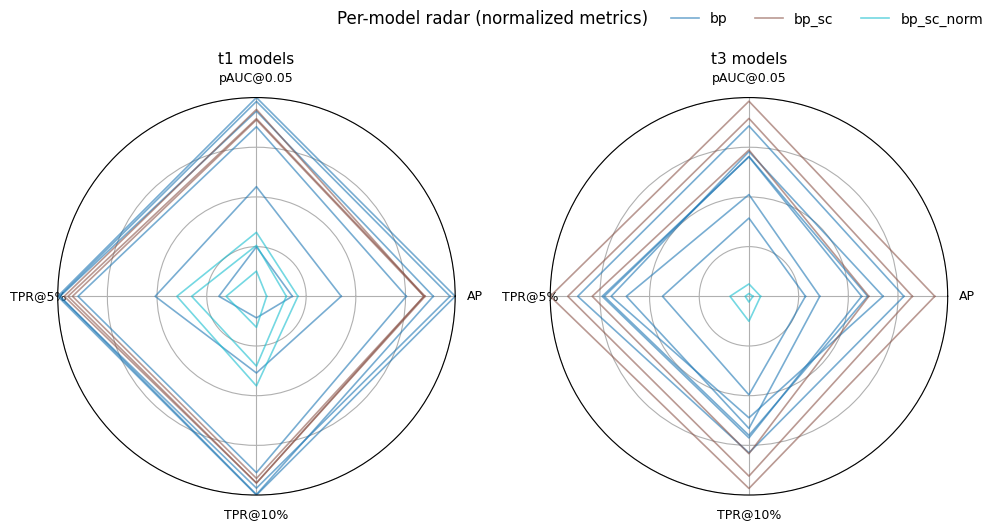

In [171]:
# --- Radar charts: one line per model, split by track ---
import numpy as np
import matplotlib.pyplot as plt

radar_metrics = ['ap','pauc_fpr0.05','tpr_top0.05','tpr_top0.10']
radar_metrics = [m for m in radar_metrics if m in df.columns]
if not radar_metrics:
    print('No radar metrics found in df.')
else:
    norm = _normalize_per_metric(df, radar_metrics)
    vals = norm.set_index('run_id')[radar_metrics]
    meta = df.set_index('run_id')[['track','preprocessing']].copy()
    vals = vals.join(meta)
    vals = vals.loc[model_order]

    def _plot_radar(track_label, ax):
        sub = vals[vals['track'] == track_label]
        if sub.empty:
            ax.set_axis_off()
            ax.set_title(f'{track_label} (no rows)')
            return
        angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False)
        angles = np.concatenate([angles, angles[:1]])
        # palette by preprocessing
        prepros = sub['preprocessing'].unique().tolist()
        colors = plt.cm.tab10(np.linspace(0, 1, max(3, len(prepros))))
        color_map = {p: colors[i] for i,p in enumerate(prepros)}
        for run_id, row in sub.iterrows():
            v = row[radar_metrics].values.astype(float)
            v = np.concatenate([v, v[:1]])
            ax.plot(angles, v, color=color_map[row['preprocessing']], alpha=0.6, lw=1.2, label=row['preprocessing'])
        ax.set_xticks(angles[:-1])
        label_map = {'ap':'AP','pauc_fpr0.05':'pAUC@0.05','tpr_top0.05':'TPR@5%','tpr_top0.10':'TPR@10%'}
        ax.set_xticklabels([label_map[m] for m in radar_metrics], fontsize=9)
        ax.set_yticks([0.25,0.5,0.75,1.0])
        ax.set_yticklabels([])
        ax.set_ylim(0,1)
        ax.set_title(f'{track_label} models', fontsize=11)

    fig, axes = plt.subplots(1, 2, subplot_kw={'projection':'polar'}, figsize=(10, 5))
    _plot_radar('t1', axes[0])
    _plot_radar('t3', axes[1])

    # build legend from preprocessing regimes
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        handles, labels = axes[1].get_legend_handles_labels()
    if handles:
        # unique by label
        uniq = dict(zip(labels, handles))
        fig.legend(uniq.values(), uniq.keys(), loc='upper right', ncol=min(3, len(uniq)), frameon=False)

    fig.suptitle('Per-model radar (normalized metrics)', y=1.02)
    plt.tight_layout()
    plt.show()


## Slope chart (normalized metrics per model)
Shows whether top models stay high across all metrics.


In [172]:
# --- Slope chart (normalized per metric) ---
metric_order = ['ap','pauc_fpr0.05','tpr_top0.05','tpr_top0.10']
metric_order = [m for m in metric_order if m in df.columns]

norm = _normalize_per_metric(df, metric_order)
norm['score_mean'] = norm[metric_order].mean(axis=1)
order_by_mean = norm.sort_values('score_mean', ascending=False)['run_id'].tolist()

long = norm.melt(id_vars=['run_id','score_mean'], value_vars=metric_order, var_name='metric', value_name='value')
long['metric'] = pd.Categorical(long['metric'], categories=metric_order, ordered=True)
long['run_id'] = pd.Categorical(long['run_id'], categories=order_by_mean, ordered=True)

# label only top N to reduce clutter
top_n = 24
top_ids = set(order_by_mean[:top_n])
long['label'] = long['run_id'].astype(str).where(long['run_id'].isin(top_ids), '')

base = alt.Chart(long).encode(
    x=alt.X('metric:N', sort=metric_order, title=None),
    y=alt.Y('value:Q', title='Normalized score'),
    detail='run_id:N'
)

lines = base.mark_line(opacity=0.25, strokeWidth=1.2).encode(
    color=alt.Color('run_id:N', legend=None)
)

points = base.mark_point(size=18, opacity=0.4).encode(color=alt.Color('run_id:N', legend=None))

labels = base.mark_text(align='left', dx=4, dy=0, fontSize=9).encode(
    text='label:N'
).transform_filter(alt.datum.metric == metric_order[-1])

chart = (lines + points + labels).properties(width=400, height=1000, title='Normalized metric profiles per model (top labels shown)')
chart


alt.LayerChart(...)

## Altair slope chart (fold pattern)


In [173]:
# --- Altair slope chart (melted dataframe; robust) ---
metric_order = ['ap','pauc_fpr0.05','tpr_top0.05','tpr_top0.10']
metric_order = [m for m in metric_order if m in df.columns]

norm = _normalize_per_metric(df, metric_order)
norm = norm[['run_id'] + metric_order].copy()
for m in metric_order:
    norm[m] = pd.to_numeric(norm[m], errors='coerce')
norm = norm.dropna(subset=metric_order)

# order by mean score
norm['score_mean'] = norm[metric_order].mean(axis=1)
order_by_mean = norm.sort_values('score_mean', ascending=False)['run_id'].tolist()

long = norm.melt(id_vars=['run_id','score_mean'], value_vars=metric_order, var_name='metric', value_name='value')
long['metric'] = pd.Categorical(long['metric'], categories=metric_order, ordered=True)
long['run_id'] = pd.Categorical(long['run_id'], categories=order_by_mean, ordered=True)

print('slope rows:', len(long), 'models:', long['run_id'].nunique())
display(long.head())

base = alt.Chart(long).encode(
    x=alt.X('metric:N', sort=metric_order, title=None),
    y=alt.Y('value:Q', title='Normalized score', scale=alt.Scale(domain=[0,1])),
    detail='run_id:N'
)

lines = base.mark_line(opacity=0.55, strokeWidth=1.2).encode(
    color=alt.Color('run_id:N', legend=None)
)
pts = base.mark_point(size=25, opacity=0.5).encode(color=alt.Color('run_id:N', legend=None))

(lines + pts).properties(width=520, height=260, title='Normalized metric profiles per model')


slope rows: 96 models: 24


,run_id,score_mean,metric,value
0,t1-exp01-bp-bce,0.951553,ap,0.889667
1,t1-exp02-bp-bce-rot10,0.181744,ap,0.180707
2,t1-exp03-bp-focal,1.000000,ap,1.000000
3,t1-exp04-bp-focal-rot10,0.977798,ap,0.974038
4,t1-exp05-bp-rat,0.848016,ap,0.753872


alt.LayerChart(...)

## Embedding metrics heatmap (GPU/CAC/SAA by class)


In [174]:
# --- Embedding metrics heatmap (GPU/CAC/SAA by class) ---
emb_path = root / 'analysis/embeddings_probe/embedding_metrics.csv'

emb = pd.read_csv(emb_path)
# Use encoder space if present
if 'space' in emb.columns:
    emb = emb[emb['space'] == 'enc']

# pick metrics
emb_metrics = ['GPU_0','GPU_1','CAC_0','CAC_1','SAA_0','SAA_1']
emb_metrics = [m for m in emb_metrics if m in emb.columns]
    
# normalize per metric; invert GPU so higher is better
emb_norm = emb[['run_id'] + emb_metrics].copy()
for m in emb_metrics:
    col = pd.to_numeric(emb_norm[m], errors='coerce')
    vmin, vmax = col.min(), col.max()
    if pd.isna(vmin) or pd.isna(vmax) or vmin == vmax:
        emb_norm[m] = 0.5
    else:
        scaled = (col - vmin) / (vmax - vmin)
        if m.startswith('GPU_'):
            scaled = 1.0 - scaled
        emb_norm[m] = scaled

emb_long = emb_norm.melt('run_id', var_name='metric', value_name='value')
emb_long['run_id'] = pd.Categorical(emb_long['run_id'], categories=model_order, ordered=True)

heat_emb = (
    alt.Chart(emb_long)
    .mark_rect()
    .encode(
        x=alt.X('run_id:N', sort=model_order, title='Model'),
        y=alt.Y('metric:N', title=None),
        color=alt.Color('value:Q', scale=alt.Scale(scheme='magma'), title='normalized'),
        tooltip=['run_id:N','metric:N', alt.Tooltip('value:Q', format='.3f')]
    )
    .properties(width=18*len(model_order), height=18*len(emb_metrics), title='Embedding metrics (GPU inverted)')
)
heat_emb


alt.Chart(...)

In [175]:
# plot a heatmap of combined classification (only the overall, not verified/code15 metrics) and embedding metrics